In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression


Dataset:

Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of
Information and Computer Science.

Source: Data Source :http://data.seoul.go.kr/ SOUTH KOREA PUBLIC HOLIDAYS. URL: publicholidays.go.kr

In [3]:
df = pd.read_csv("SeoulBikeData.csv", encoding="unicode_escape")

df.columns = [
    "date", "bike_count", "hour", "temp", "humidity", "wind",
    "visibility", "dew_pt_temp", "radiation", "rainfall",
    "snowfall", "seasons", "holiday", "functional"
]

df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12]
df = df.drop(columns=["date", "hour"])

# Encode BEFORE get_xy
df = pd.get_dummies(df, columns=["seasons", "holiday"])
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

In [4]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)
train = df_shuffled.iloc[:int(0.6 * len(df_shuffled))]
val   = df_shuffled.iloc[int(0.6 * len(df_shuffled)):int(0.8 * len(df_shuffled))]
test  = df_shuffled.iloc[int(0.8 * len(df_shuffled)):]

In [5]:
print(df.columns.tolist())

['bike_count', 'temp', 'humidity', 'wind', 'visibility', 'dew_pt_temp', 'radiation', 'rainfall', 'snowfall', 'functional', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'holiday_Holiday', 'holiday_No Holiday']


In [6]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rainfall,snowfall,functional,seasons_Autumn,seasons_Spring,seasons_Summer,seasons_Winter,holiday_Holiday,holiday_No Holiday
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1,0,0,0,1,0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1,0,0,0,1,0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1,0,0,0,1,0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1,0,0,0,1,0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1,0,0,0,1,0,1


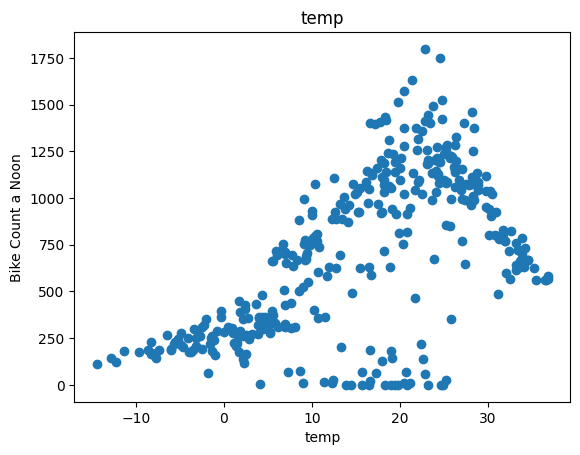

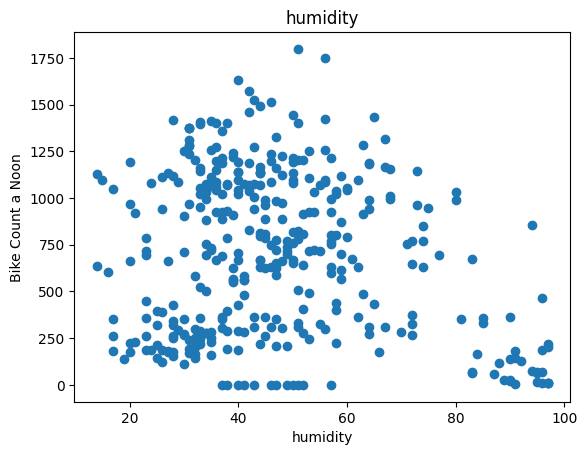

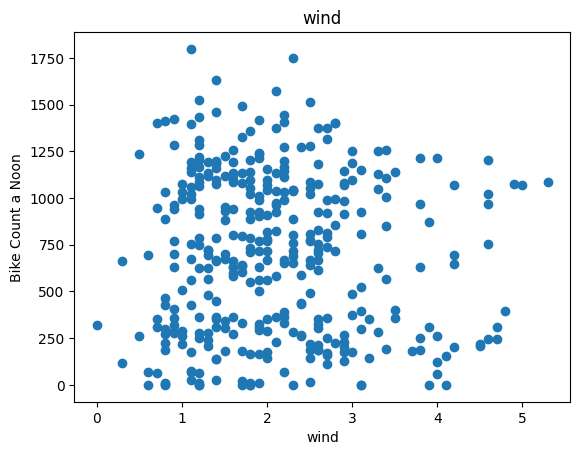

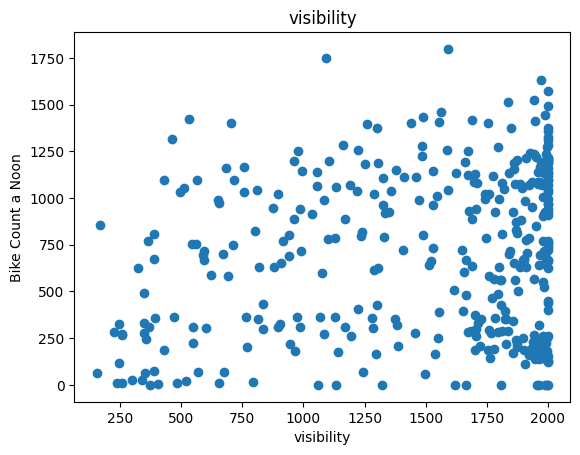

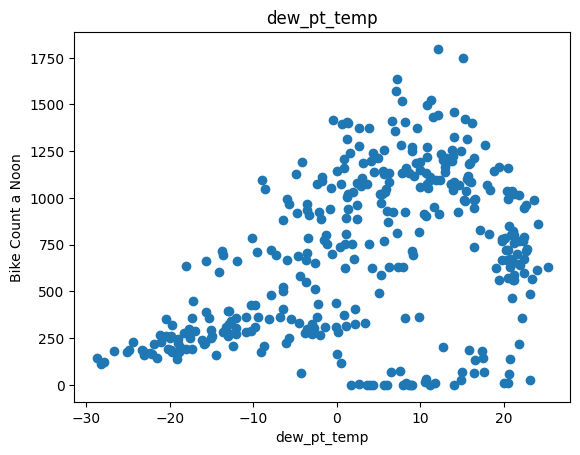

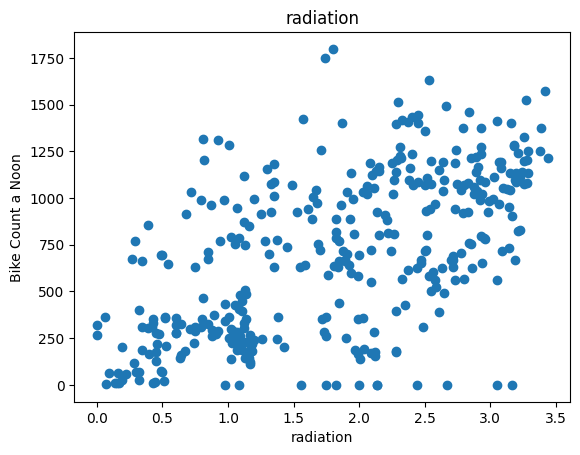

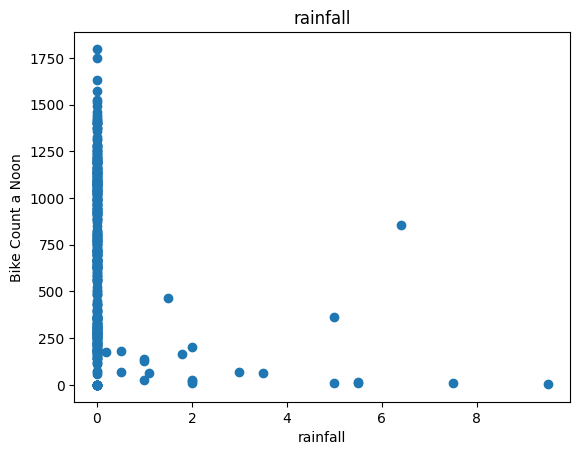

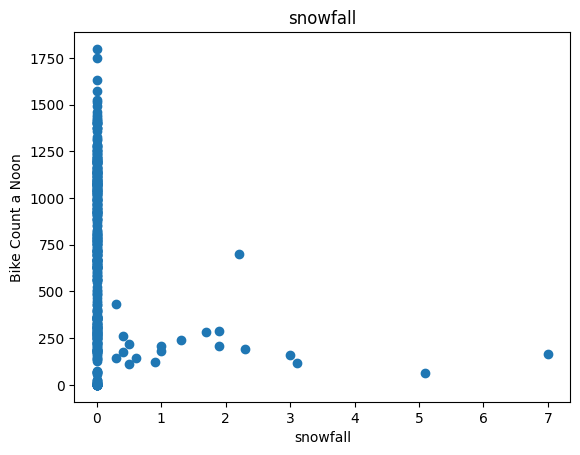

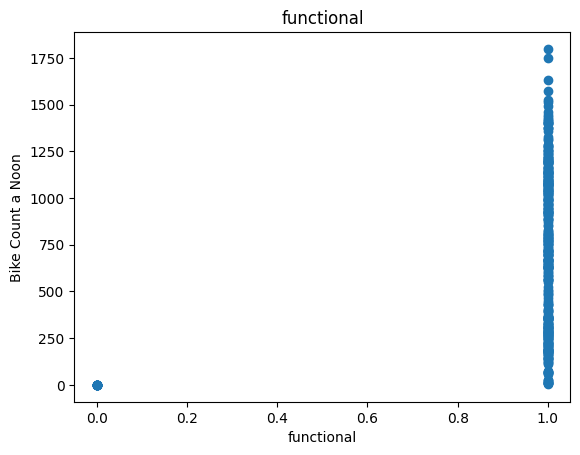

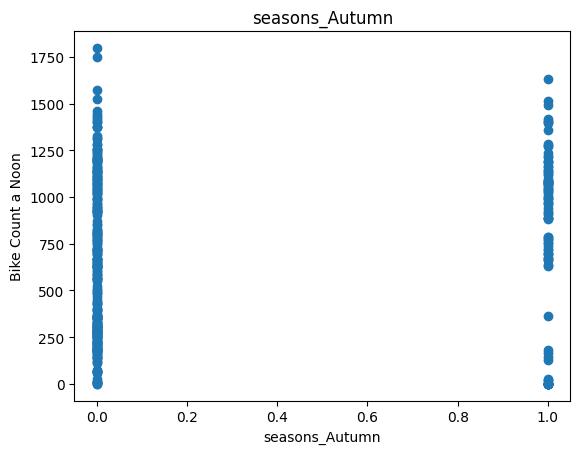

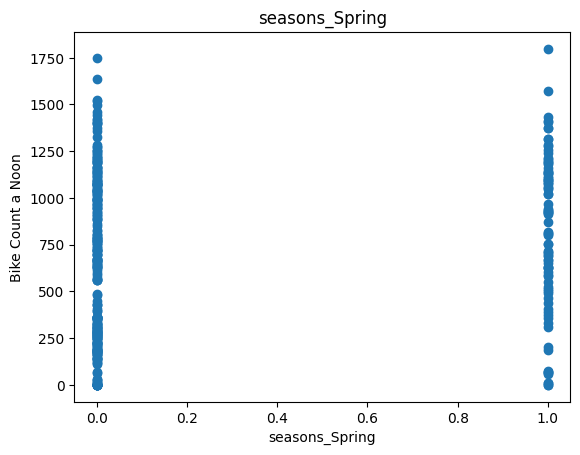

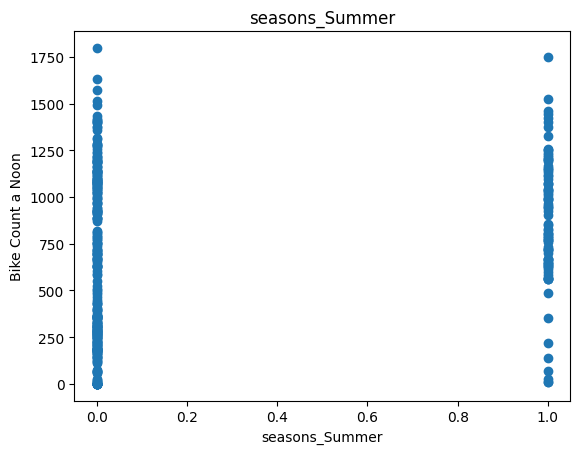

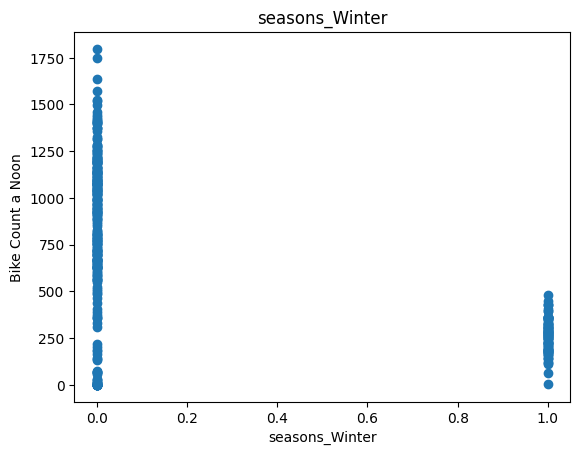

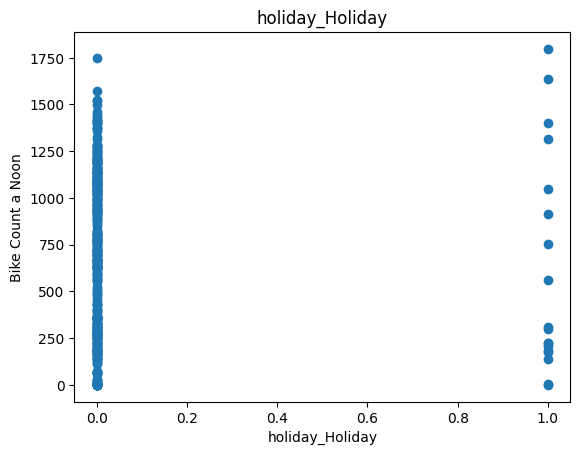

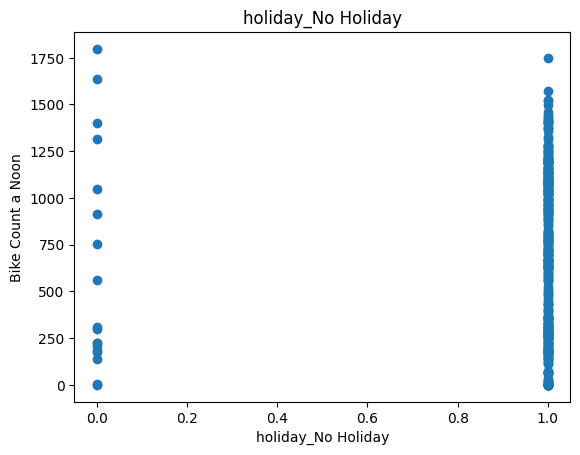

In [7]:
for label in df.columns[1:]:
    plt.scatter(df[label],df["bike_count"])
    plt.title(label)
    plt.ylabel("Bike Count a Noon")
    plt.xlabel(label)
    plt.show()

In [8]:
df = df.drop(["wind","visibility","functional"], axis=1)

In [9]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rainfall,snowfall,seasons_Autumn,seasons_Spring,seasons_Summer,seasons_Winter,holiday_Holiday,holiday_No Holiday
12,449,1.7,23,-17.2,1.11,0.0,0.0,0,0,0,1,0,1
36,479,4.3,41,-7.8,1.09,0.0,0.0,0,0,0,1,0,1
60,333,5.8,85,3.4,0.43,0.0,0.0,0,0,0,1,0,1
84,393,-0.3,38,-12.9,1.11,0.0,0.0,0,0,0,1,0,1
108,321,-2.3,25,-19.7,0.00,0.0,0.0,0,0,0,1,0,1


Train/valid/test dataset

In [10]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)
n = len(df_shuffled)
train = df_shuffled.iloc[:int(0.6 * n)]
val   = df_shuffled.iloc[int(0.6 * n):int(0.8 * n)]
test  = df_shuffled.iloc[int(0.8 * n):]

In [11]:
def get_xy(dataframe, y_label, x_label=None):
    dataframe = copy.deepcopy(dataframe)
    if x_label is None:
        x = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if len(x_label) == 1:
            x = dataframe[x_label[0]].values.reshape(-1, 1)
        else:
            x = dataframe[x_label].values
    y = dataframe[y_label].values.reshape(-1, 1)
    data = np.hstack((x, y))
    return data, x, y

In [12]:
_, x_train_temp, y_train_temp = get_xy(train, "bike_count", x_label=["temp"])
_, x_val_temp, y_val_temp = get_xy(val, "bike_count", x_label=["temp"])
_, x_test_temp, y_test_temp = get_xy(test, "bike_count", x_label=["temp"])

In [13]:
x_train_temp = x_train_temp.astype(np.float32)
x_val_temp   = x_val_temp.astype(np.float32)
x_test_temp  = x_test_temp.astype(np.float32)
y_train_temp = y_train_temp.astype(np.float32)
y_val_temp   = y_val_temp.astype(np.float32)
y_test_temp  = y_test_temp.astype(np.float32)

In [14]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp, y_train_temp)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
temp_reg.score(x_test_temp, y_test_temp)

0.34912657737731934

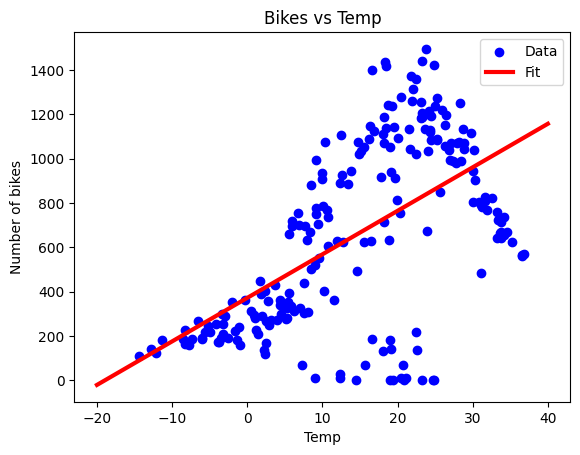

In [16]:
plt.scatter(x_train_temp, y_train_temp, label="Data",color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

Multiple Linear Regression

In [17]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)

train = df_shuffled.iloc[:int(0.6 * len(df_shuffled))]
val   = df_shuffled.iloc[int(0.6 * len(df_shuffled)):int(0.8 * len(df_shuffled))]
test  = df_shuffled.iloc[int(0.8 * len(df_shuffled)):]

_, X_train_all, y_train_all = get_xy(train, "bike_count", x_label=df.columns[1:].tolist())
_, X_val_all,   y_val_all   = get_xy(val,   "bike_count", x_label=df.columns[1:].tolist())
_, X_test_all,  y_test_all  = get_xy(test,  "bike_count", x_label=df.columns[1:].tolist())

In [18]:
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
all_reg.score(X_test_all, y_test_all)

0.6177569050712521

Regression with Neural Net

In [21]:
temp_normalizer = tf.keras.layers.Normalization(axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))